In [6]:
import pandas as pd
import matplotlib.pyplot as plt

acc1 = pd.read_csv("../Human_Activity_Recognition/dataset/RawData/acc_exp01_user01.txt", 
                    sep=r'\s+', header=None, names=['acc_x', 'acc_y', 'acc_z'])
acc1.shape

(20598, 3)

In [7]:
acc1.head()

,acc_x,acc_y,acc_z
0,0.918056,-0.112500,0.509722
1,0.911111,-0.093056,0.537500
2,0.881944,-0.086111,0.513889
3,0.881944,-0.086111,0.513889
4,0.879167,-0.100000,0.505556


In [8]:
acc1.describe()

,acc_x,acc_y,acc_z
count,20598.000000,20598.000000,20598.000000
mean,0.880673,-0.101714,0.097088
std,0.346449,0.340091,0.285555
min,-0.647222,-1.209722,-0.676389
25%,0.805556,-0.285764,-0.081944
50%,0.981945,-0.202778,-0.004167
75%,1.019445,-0.031944,0.204167
max,1.950000,1.036111,1.269444


In [9]:
gyro1 = pd.read_csv("../Human_Activity_Recognition/dataset/RawData/gyro_exp01_user01.txt", sep=r'\s+', header=None, names=['gyro_x', 'gyro_y', 'gyro_z'])
gyro1.shape

(20598, 3)

In [10]:
gyro1.head()

,gyro_x,gyro_y,gyro_z
0,-0.054978,-0.069639,-0.030849
1,-0.012523,0.019242,-0.038485
2,-0.023518,0.276417,0.006414
3,-0.093462,0.367741,0.001222
4,-0.124311,0.476780,-0.022907


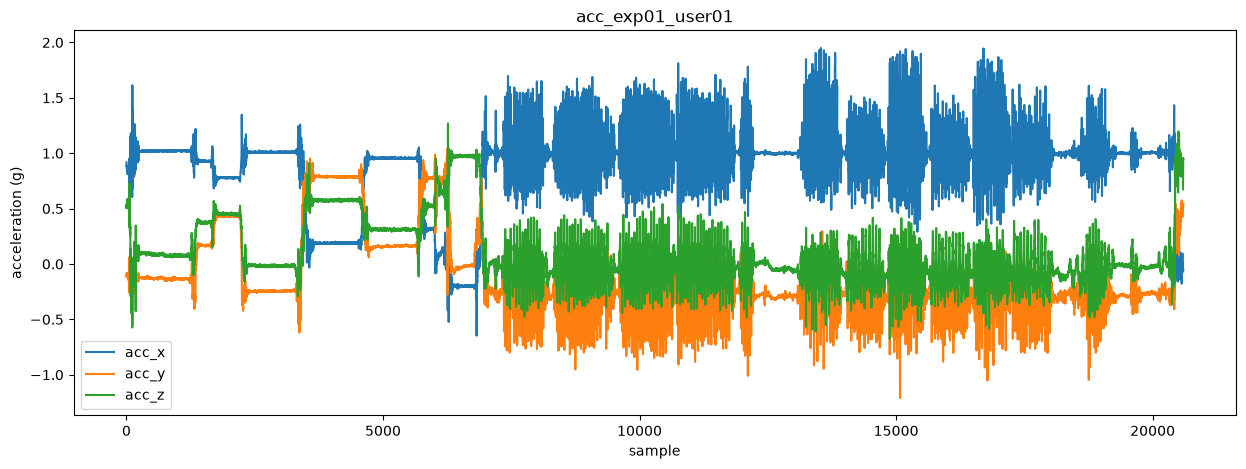

In [11]:
plt.figure(figsize=(15, 5))
plt.plot(acc1['acc_x'], label='acc_x')
plt.plot(acc1['acc_y'], label='acc_y')
plt.plot(acc1['acc_z'], label='acc_z')
plt.legend()
plt.xlabel('sample')
plt.ylabel('acceleration (g)')
plt.title('acc_exp01_user01')
plt.show()

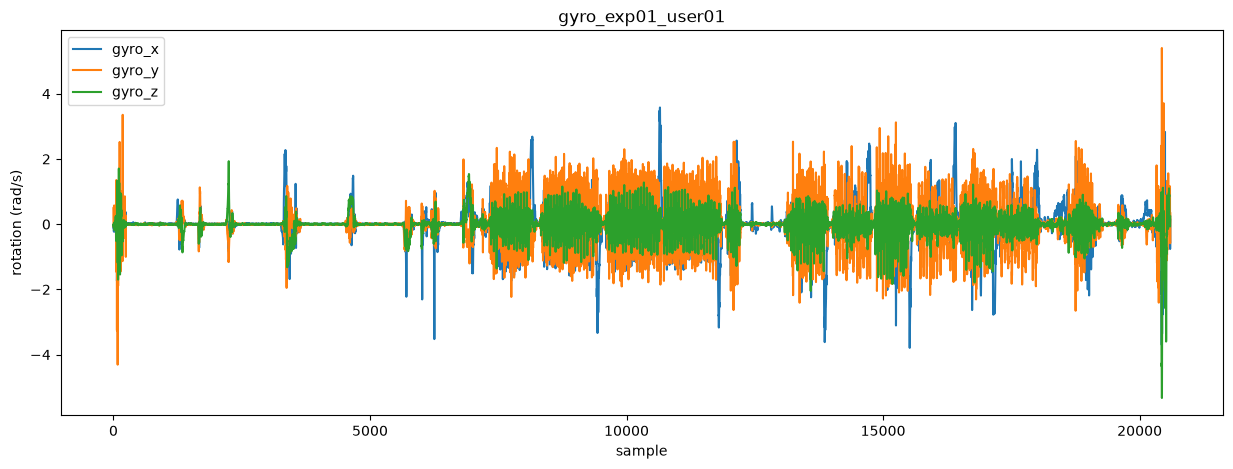

In [12]:
plt.figure(figsize=(15, 5))
plt.plot(gyro1['gyro_x'], label='gyro_x')
plt.plot(gyro1['gyro_y'], label='gyro_y')
plt.plot(gyro1['gyro_z'], label='gyro_z')
plt.legend()
plt.xlabel('sample')
plt.ylabel('rotation (rad/s)')
plt.title('gyro_exp01_user01')
plt.show()

In [13]:
labels = pd.read_csv("../Human_Activity_Recognition/dataset/RawData/labels.txt", 
                    sep=r'\s+', header=None, 
                    names=['experiment_number_ID', 'user_number_ID', 'activity_number_ID', 'label_start_point', 'label_end_point'])
labels.shape


(1214, 5)

In [34]:
labels.head(30)

,experiment_number_ID,user_number_ID,activity_number_ID,label_start_point,label_end_point
0,1,1,5,250,1232
1,1,1,7,1233,1392
2,1,1,4,1393,2194
3,1,1,8,2195,2359
4,1,1,5,2360,3374
5,1,1,11,3375,3662
6,1,1,6,3663,4538
7,1,1,10,4539,4735
8,1,1,4,4736,5667
9,1,1,9,5668,5859


In [15]:
activity_labels = pd.read_csv("../Human_Activity_Recognition/dataset/activity_labels.txt", 
                              sep=r'\s+', header=None, names=['activity_number_id', 'activity_label'])
activity_labels.shape

(12, 2)

In [16]:
activity_labels.head(12)

,activity_number_id,activity_label
0,1,WALKING
1,2,WALKING_UPSTAIRS
2,3,WALKING_DOWNSTAIRS
3,4,SITTING
4,5,STANDING
5,6,LAYING
6,7,STAND_TO_SIT
7,8,SIT_TO_STAND
8,9,SIT_TO_LIE
9,10,LIE_TO_SIT


In [17]:
labels1 = labels[labels['experiment_number_ID'] == 1] #how many labeled segments does experiment1 have
labels1.head(30)

,experiment_number_ID,user_number_ID,activity_number_ID,label_start_point,label_end_point
0,1,1,5,250,1232
1,1,1,7,1233,1392
2,1,1,4,1393,2194
3,1,1,8,2195,2359
4,1,1,5,2360,3374
5,1,1,11,3375,3662
6,1,1,6,3663,4538
7,1,1,10,4539,4735
8,1,1,4,4736,5667
9,1,1,9,5668,5859


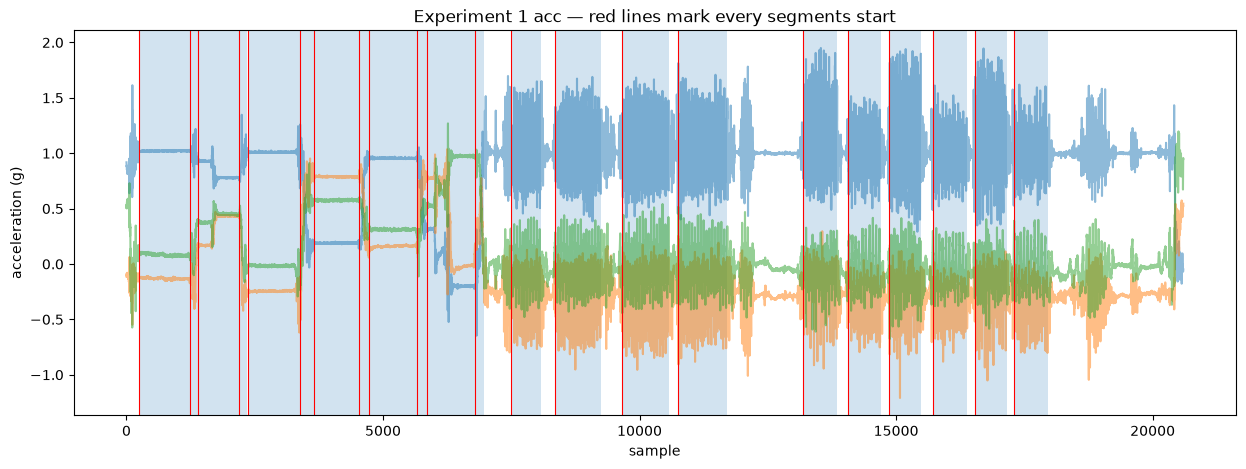

In [18]:
plt.figure(figsize=(15, 5))
plt.plot(acc1['acc_x'], alpha=0.5)
plt.plot(acc1['acc_y'], alpha=0.5)
plt.plot(acc1['acc_z'], alpha=0.5)

for _, row in labels1.iterrows():
    plt.axvspan(row['label_start_point'], row['label_end_point'], alpha=0.2)
    #draw a vertical line at the start of each segment
    plt.axvline(row['label_start_point'], color='red', linewidth=0.8)

plt.xlabel('sample')
plt.ylabel('acceleration (g)')
plt.title('Experiment 1 acc — red lines mark every segments start')
plt.show()

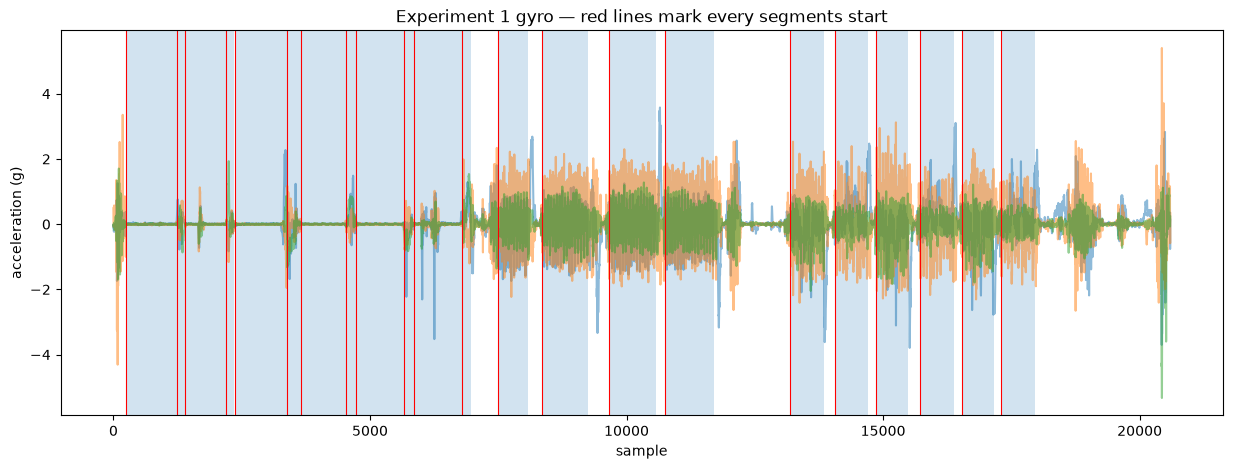

In [19]:
plt.figure(figsize=(15, 5))
plt.plot(gyro1['gyro_x'], alpha=0.5)
plt.plot(gyro1['gyro_y'], alpha=0.5)
plt.plot(gyro1['gyro_z'], alpha=0.5)

for _, row in labels1.iterrows():
    plt.axvspan(row['label_start_point'], row['label_end_point'], alpha=0.2)
    #draw a vertical line at the start of each segment
    plt.axvline(row['label_start_point'], color='red', linewidth=0.8)

plt.xlabel('sample')
plt.ylabel('acceleration (g)')
plt.title('Experiment 1 gyro — red lines mark every segments start')
plt.show()

In [20]:
WINDOW_SIZE = 128 #samples per window, 2.56 s at 50 Hz
STEP = 128 #how far we slide between windows, each window starts exactly where the last ended, no overlap

In [21]:
#concatenating the acc1 and gyro1
signals1 = pd.concat([acc1, gyro1], axis=1)
print(signals1.shape)
print(signals1.head())
print(signals1.describe())

(20598, 6)
      acc_x     acc_y     acc_z    gyro_x    gyro_y    gyro_z
0  0.918056 -0.112500  0.509722 -0.054978 -0.069639 -0.030849
1  0.911111 -0.093056  0.537500 -0.012523  0.019242 -0.038485
2  0.881944 -0.086111  0.513889 -0.023518  0.276417  0.006414
3  0.881944 -0.086111  0.513889 -0.093462  0.367741  0.001222
4  0.879167 -0.100000  0.505556 -0.124311  0.476780 -0.022907
              acc_x         acc_y         acc_z        gyro_x        gyro_y  \
count  20598.000000  20598.000000  20598.000000  20598.000000  20598.000000   
mean       0.880673     -0.101714      0.097088      0.012414     -0.009303   
std        0.346449      0.340091      0.285555      0.565569      0.545089   
min       -0.647222     -1.209722     -0.676389     -3.794084     -4.308127   
25%        0.805556     -0.285764     -0.081944     -0.082085     -0.165239   
50%        0.981945     -0.202778     -0.004167      0.007330     -0.003054   
75%        1.019445     -0.031944      0.204167      0.160047   

In [22]:
all_windows = []  #will hold every window from every segment
all_labels  = []  #the activity id for each window (same length as all_windows)

#go through each labeled segment
for _, seg in labels1.iterrows():
    start = seg['label_start_point']
    end = seg['label_end_point']
    activity = seg['activity_number_ID']

    segment = signals1.iloc[start:end+1] #slice the signal for this segment

    #window this segment
    for start_idx in range(0, len(segment) - WINDOW_SIZE + 1, STEP):
        window = segment.iloc[start_idx : start_idx + WINDOW_SIZE]
        all_windows.append(window)
        all_labels.append(activity) #tag this window with its activity

print("total windows:", len(all_windows))
print("total labels:", len(all_labels))

print(all_labels)
print(all_windows)

total windows: 98
total labels: 98
[np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(7), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(8), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(11), np.int64(11), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(10), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(12), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(3), np.int64(3), np.int64(3)

In [23]:
print(all_windows[0].shape)

(128, 6)


In [24]:
w = all_windows[0] #the first window

print(w.mean()) # mean of each column
print(w.std()) # std of each column
print(w.min())
print(w.max())

acc_x     1.019314
acc_y    -0.124284
acc_z     0.099403
gyro_x    0.008018
gyro_y   -0.002849
gyro_z    0.002467
dtype: float64
acc_x     0.002486
acc_y     0.003866
acc_z     0.005060
gyro_x    0.011023
gyro_y    0.005399
gyro_z    0.006158
dtype: float64
acc_x     1.012500
acc_y    -0.134722
acc_z     0.080556
gyro_x   -0.013134
gyro_y   -0.021380
gyro_z   -0.014050
dtype: float64
acc_x     1.027778
acc_y    -0.115278
acc_z     0.109722
gyro_x    0.043677
gyro_y    0.011912
gyro_z    0.016799
dtype: float64


In [25]:
features = pd.concat([w.mean(), w.std(), w.min(), w.max()])
print(features)
print("number of features:", len(features))

acc_x     1.019314
acc_y    -0.124284
acc_z     0.099403
gyro_x    0.008018
gyro_y   -0.002849
gyro_z    0.002467
acc_x     0.002486
acc_y     0.003866
acc_z     0.005060
gyro_x    0.011023
gyro_y    0.005399
gyro_z    0.006158
acc_x     1.012500
acc_y    -0.134722
acc_z     0.080556
gyro_x   -0.013134
gyro_y   -0.021380
gyro_z   -0.014050
acc_x     1.027778
acc_y    -0.115278
acc_z     0.109722
gyro_x    0.043677
gyro_y    0.011912
gyro_z    0.016799
dtype: float64
number of features: 24


In [26]:
def extract_features(window):
    """Take one 128x6 window, return a flat row of 24 uniquely-named features."""
    feats = {}
    for col in window.columns:  # loop over the 6 signals
        feats[f'{col}_mean'] = window[col].mean()
        feats[f'{col}_std']  = window[col].std()
        feats[f'{col}_min']  = window[col].min()
        feats[f'{col}_max']  = window[col].max()
    return pd.Series(feats)

In [27]:
f0 = extract_features(all_windows[0]) #standing
print(f0)
print(len(f0))

acc_x_mean     1.019314
acc_x_std      0.002486
acc_x_min      1.012500
acc_x_max      1.027778
acc_y_mean    -0.124284
acc_y_std      0.003866
acc_y_min     -0.134722
acc_y_max     -0.115278
acc_z_mean     0.099403
acc_z_std      0.005060
acc_z_min      0.080556
acc_z_max      0.109722
gyro_x_mean    0.008018
gyro_x_std     0.011023
gyro_x_min    -0.013134
gyro_x_max     0.043677
gyro_y_mean   -0.002849
gyro_y_std     0.005399
gyro_y_min    -0.021380
gyro_y_max     0.011912
gyro_z_mean    0.002467
gyro_z_std     0.006158
gyro_z_min    -0.014050
gyro_z_max     0.016799
dtype: float64
24


In [28]:
f50 = extract_features(all_windows[50]) #walking
print(f50)
print(len(f50))

acc_x_mean     1.019000
acc_x_std      0.255319
acc_x_min      0.512500
acc_x_max      1.648611
acc_y_mean    -0.223850
acc_y_std      0.192509
acc_y_min     -0.768056
acc_y_max      0.134722
acc_z_mean    -0.013618
acc_z_std      0.158845
acc_z_min     -0.344444
acc_z_max      0.420833
gyro_x_mean   -0.025819
gyro_x_std     0.464155
gyro_x_min    -1.406517
gyro_x_max     0.848797
gyro_y_mean   -0.013976
gyro_y_std     0.741411
gyro_y_min    -1.323440
gyro_y_max     1.618182
gyro_z_mean    0.021173
gyro_z_std     0.354120
gyro_z_min    -0.825279
gyro_z_max     0.983188
dtype: float64
24


In [29]:
feature_rows = []   # will hold one 24-feature row per window

for w in all_windows:
    feature_rows.append(extract_features(w))

# stack the list of rows into a table
X_exp1 = pd.DataFrame(feature_rows)
print(X_exp1.shape)
X_exp1.head()

(98, 24)


,acc_x_mean,acc_x_std,acc_x_min,acc_x_max,acc_y_mean,acc_y_std,acc_y_min,acc_y_max,acc_z_mean,acc_z_std,...,gyro_x_min,gyro_x_max,gyro_y_mean,gyro_y_std,gyro_y_min,gyro_y_max,gyro_z_mean,gyro_z_std,gyro_z_min,gyro_z_max
0,1.019314,0.002486,1.012500,1.027778,-0.124284,0.003866,-0.134722,-0.115278,0.099403,0.005060,...,-0.013134,0.043677,-0.002849,0.005399,-0.021380,0.011912,0.002467,0.006158,-0.014050,0.016799
1,1.019900,0.003380,1.009722,1.029167,-0.125054,0.006927,-0.137500,-0.108333,0.092828,0.007722,...,-0.030543,0.059254,-0.006698,0.008212,-0.034514,0.012828,0.005443,0.009819,-0.014355,0.036346
2,1.020150,0.002761,1.011111,1.025000,-0.130187,0.004543,-0.141667,-0.119444,0.085135,0.005384,...,-0.018021,0.053451,-0.000122,0.008680,-0.026267,0.025962,0.000344,0.009042,-0.023824,0.027184
3,1.020779,0.002882,1.013889,1.027778,-0.127637,0.007427,-0.154167,-0.111111,0.085536,0.006923,...,-0.026573,0.027184,-0.005178,0.010789,-0.033903,0.012828,0.006118,0.012624,-0.024435,0.033598
4,1.020551,0.002802,1.012500,1.027778,-0.138455,0.005631,-0.152778,-0.125000,0.074056,0.005066,...,-0.011301,0.032681,-0.000095,0.008765,-0.037874,0.018326,0.000091,0.008607,-0.020159,0.025045


In [30]:
exp_num = 1
print(f'acc_exp{exp_num:02d}_user01.txt') 

acc_exp01_user01.txt


In [35]:
exp_user_pairs = labels[['experiment_number_ID', 'user_number_ID']].drop_duplicates()
print(exp_user_pairs.shape)
print(exp_user_pairs)

(61, 2)
      experiment_number_ID  user_number_ID
0                        1               1
22                       2               1
45                       3               2
65                       4               2
85                       5               3
...                    ...             ...
1115                    57              28
1133                    58              29
1154                    59              29
1174                    60              30
1194                    61              30

[61 rows x 2 columns]


In [36]:
def process_experiment(exp_num, user_num, labels, data_dir):
    """Load one experiment, window it, extract features.
    Returns three aligned lists: feature rows, activity labels, user ids."""

    # 1. Build the two filenames (with zero-padding)
    acc_path  = f'{data_dir}/acc_exp{exp_num:02d}_user{user_num:02d}.txt'
    gyro_path = f'{data_dir}/gyro_exp{exp_num:02d}_user{user_num:02d}.txt'

    # 2. Load both sensors
    acc  = pd.read_csv(acc_path,  sep=r'\s+', header=None, names=['acc_x','acc_y','acc_z'])
    gyro = pd.read_csv(gyro_path, sep=r'\s+', header=None, names=['gyro_x','gyro_y','gyro_z'])

    # 3. Glue into one 6-column signal
    signals = pd.concat([acc, gyro], axis=1)

    # 4. Filter labels to THIS experiment
    exp_labels = labels[labels['experiment_number_ID'] == exp_num]

    # 5. Window each segment + extract features
    feature_rows = []
    label_list   = []
    user_list    = []

    for _, seg in exp_labels.iterrows():
        start    = seg['label_start_point']
        end      = seg['label_end_point']
        activity = seg['activity_number_ID']

        segment = signals.iloc[start:end+1]

        for start_idx in range(0, len(segment) - WINDOW_SIZE + 1, STEP):
            window = segment.iloc[start_idx : start_idx + WINDOW_SIZE]
            feature_rows.append(extract_features(window))
            label_list.append(activity)
            user_list.append(user_num)

    return feature_rows, label_list, user_list

In [37]:
WINDOW_SIZE = 128
STEP = 128
data_dir = '../Human_Activity_Recognition/dataset/RawData'   # adjust to your actual path

f, l, u = process_experiment(1, 1, labels, data_dir)

print('windows:', len(f))
print('labels: ', len(l))
print('users:  ', len(u))
print('first label:', l[0], ' first user:', u[0])

windows: 98
labels:  98
users:   98
first label: 5  first user: 1


In [ ]:
all_features = []
all_activities = []
all_users = []

for _, pair in exp_user_pairs.iterrows():
    exp_num  = pair['experiment_number_ID']
    user_num = pair['user_number_ID']

    f, l, u = process_experiment(exp_num, user_num, labels, data_dir)

    all_features.extend(f)
    all_activities.extend(l)
    all_users.extend(u)

print('total windows:', len(all_features))
print('total labels: ', len(all_activities))
print('total users:  ', len(all_users))

total windows: 5773
total labels:  5773
total users:   5773


In [39]:
# 1. The feature matrix: 5773 rows x 24 feature columns
X = pd.DataFrame(all_features)

# 2. The labels, as a Series
y = pd.Series(all_activities, name='activity')

# 3. The user ids, as a Series (for subject-independent splitting later)
groups = pd.Series(all_users, name='user')

print('X shape:', X.shape)
print('y shape:', y.shape)
print('groups shape:', groups.shape)
X.head()

X shape: (5773, 24)
y shape: (5773,)
groups shape: (5773,)


,acc_x_mean,acc_x_std,acc_x_min,acc_x_max,acc_y_mean,acc_y_std,acc_y_min,acc_y_max,acc_z_mean,acc_z_std,...,gyro_x_min,gyro_x_max,gyro_y_mean,gyro_y_std,gyro_y_min,gyro_y_max,gyro_z_mean,gyro_z_std,gyro_z_min,gyro_z_max
0,1.019314,0.002486,1.012500,1.027778,-0.124284,0.003866,-0.134722,-0.115278,0.099403,0.005060,...,-0.013134,0.043677,-0.002849,0.005399,-0.021380,0.011912,0.002467,0.006158,-0.014050,0.016799
1,1.019900,0.003380,1.009722,1.029167,-0.125054,0.006927,-0.137500,-0.108333,0.092828,0.007722,...,-0.030543,0.059254,-0.006698,0.008212,-0.034514,0.012828,0.005443,0.009819,-0.014355,0.036346
2,1.020150,0.002761,1.011111,1.025000,-0.130187,0.004543,-0.141667,-0.119444,0.085135,0.005384,...,-0.018021,0.053451,-0.000122,0.008680,-0.026267,0.025962,0.000344,0.009042,-0.023824,0.027184
3,1.020779,0.002882,1.013889,1.027778,-0.127637,0.007427,-0.154167,-0.111111,0.085536,0.006923,...,-0.026573,0.027184,-0.005178,0.010789,-0.033903,0.012828,0.006118,0.012624,-0.024435,0.033598
4,1.020551,0.002802,1.012500,1.027778,-0.138455,0.005631,-0.152778,-0.125000,0.074056,0.005066,...,-0.011301,0.032681,-0.000095,0.008765,-0.037874,0.018326,0.000091,0.008607,-0.020159,0.025045
